# k-NN Classification 2 - From Scratch, Object-Oriented

> **MLCourse · Machine Learning · 02_knn_classification**

We implement `MyKNNClassifier` as a clean class with configurable `k`, distance weighting, and majority voting - then verify it against scikit-learn on REAL penguin data.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris

# load real data
penguins = sns.load_dataset('penguins').dropna()
penguins_enc = pd.get_dummies(penguins, columns=['island', 'sex'], drop_first=True)
X = penguins_enc.drop(columns='species').values
y = penguins_enc['species'].astype('category').cat.codes.values

print('Data shape:', X.shape, 'Classes:', np.unique(y))

Data shape: (333, 7) Classes: [0 1 2]


### 1. Designing the class

Public API (mirrors sklearn so it is swappable):

| method | job |
|---|---|
| `fit(X, y)` | store training data (lazy learning) |
| `predict(X)` | majority vote among k nearest neighbors |
| `predict_proba(X)` | class proportions among k neighbors |
| `score(X, y)` | return accuracy |

Key parameters: `n_neighbors` (k), `weights` ("uniform" or "distance"), `metric` (distance function).

In [2]:
class MyKNNClassifier:
    """
    k-Nearest Neighbors classifier from scratch.

    Parameters
    ----------
    n_neighbors : int, default=5
        Number of neighbors to use.
    weights : {'uniform', 'distance'}, default='uniform'
        Weight function used in prediction.
    metric : str, default='euclidean'
        Distance metric (only 'euclidean' implemented here).

    Attributes after fit
    --------------------
    X_ : ndarray (n_samples, n_features) - training data
    y_ : ndarray (n_samples,) - training labels
    classes_ : ndarray - unique class labels
    """

    def __init__(self, n_neighbors=5, weights='uniform', metric='euclidean'):
        # Configure the classifier: k, vote weighting, distance function.
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.metric = metric

    # distance computation
    def _euclidean_distance(self, X1, X2):
        """Compute pairwise Euclidean distances between X1 and X2.

        Formula:  D(x1, x2) = sqrt( sum_j (x1_j - x2_j)^2 )
        """
        # Expand the squared distance (no need to build n1*n2*d arrays):
        #   (x1 - x2)^2  =  x1^2  -  2*x1*x2  +  x2^2
        X1_sq = np.sum(X1 ** 2, axis=1, keepdims=True)   # ||x1||^2 per row
        X2_sq = np.sum(X2 ** 2, axis=1)                   # ||x2||^2 per row
        cross = X1 @ X2.T                                 # <x1, x2> pairwise
        dists = X1_sq - 2 * cross + X2_sq
        # Numerical stability: clip tiny negative round-off values to 0
        np.maximum(dists, 0, out=dists)
        return np.sqrt(dists)                             # sqrt(||x1-x2||^2)

    # fit
    def fit(self, X, y):
        """Store training data (lazy learning: no model is actually built)."""
        self.X_ = np.asarray(X, dtype=float)              # remembered examples
        self.y_ = np.asarray(y, dtype=int).ravel()        # their labels
        self.classes_ = np.unique(self.y_)                # distinct class ids
        return self

    # vote step
    def _get_votes(self, distances):
        """Return a {class: weight} vote tally for one test point.

        distance weighting: w_i = 1 / d(x, x_i)   (closer => more weight)
        uniform weighting:  w_i = 1
        """
        # Indices of the k smallest distances (the k nearest neighbours)
        k = min(self.n_neighbors, len(self.y_))
        nearest_idx = np.argpartition(distances, k)[:k]
        nearest_dist = distances[nearest_idx]
        nearest_labels = self.y_[nearest_idx]

        if self.weights == 'distance':
            # w = 1/d ; +1e-10 avoids division by zero at d = 0
            weights = 1.0 / (nearest_dist + 1e-10)
        else:
            weights = np.ones(k)

        # vote(c) = sum of w_i over neighbours belonging to class c
        votes = {}
        for label, w in zip(nearest_labels, weights):
            votes[label] = votes.get(label, 0) + w
        return votes

    # predict
    def predict(self, X):
        """Assign the class with the most (weighted) votes among the k neighbours."""
        X = np.asarray(X, dtype=float)
        distances = self._euclidean_distance(X, self.X_)  # (n_test, n_train)
        preds = []
        for i in range(len(X)):
            votes = self._get_votes(distances[i])
            preds.append(max(votes, key=votes.get))       # argmax_c vote(c)
        return np.array(preds)

    # predict_proba
    def predict_proba(self, X):
        """Return per-class probabilities for each test point.

        Formula:  P(class c | x) = vote(c) / sum_c' vote(c')
        """
        X = np.asarray(X, dtype=float)
        distances = self._euclidean_distance(X, self.X_)
        n_classes = len(self.classes_)
        probas = np.zeros((len(X), n_classes))

        for i in range(len(X)):
            votes = self._get_votes(distances[i])
            total = sum(votes.values())
            for j, cls in enumerate(self.classes_):
                probas[i, j] = votes.get(cls, 0) / total if total > 0 else 0
        return probas

    # score
    def score(self, X, y):
        """Return prediction accuracy on (X, y)."""
        return accuracy_score(y, self.predict(X))

    def __repr__(self):
        return (f"MyKNNClassifier(n_neighbors={self.n_neighbors}, "
                f"weights={self.weights!r}, metric={self.metric!r})")

print('MyKNNClassifier class defined')


MyKNNClassifier class defined


### 2. Sanity check on real data - penguins (multi-class)

Compare our implementation with sklearn on the full penguin dataset with scaling.

In [3]:
# Split and scale
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# Our implementation
mine = MyKNNClassifier(n_neighbors=5, weights='distance').fit(X_tr_s, y_tr)
pred_mine = mine.predict(X_te_s)
acc_mine = accuracy_score(y_te, pred_mine)

# sklearn
sk = KNeighborsClassifier(n_neighbors=5, weights='distance').fit(X_tr_s, y_tr)
pred_sk = sk.predict(X_te_s)
acc_sk = accuracy_score(y_te, pred_sk)

print(f'MyKNNClassifier accuracy:  {acc_mine:.4f}')
print(f'sklearn KNeighborsClassifier accuracy: {acc_sk:.4f}')
print(f'Difference: {abs(acc_mine - acc_sk):.4f}')

MyKNNClassifier accuracy:  0.9881
sklearn KNeighborsClassifier accuracy: 0.9881
Difference: 0.0000


### 3. Effect of k and weighting on real data

Sweep k and compare uniform vs distance weighting on the test set.

In [4]:
ks = range(1, 31, 2)
results = []

for k in ks:
    for w in ['uniform', 'distance']:
        m = MyKNNClassifier(n_neighbors=k, weights=w).fit(X_tr_s, y_tr)
        s = KNeighborsClassifier(n_neighbors=k, weights=w).fit(X_tr_s, y_tr)
        results.append({
            'k': k, 'weights': w,
            'mine': accuracy_score(y_te, m.predict(X_te_s)),
            'sklearn': accuracy_score(y_te, s.predict(X_te_s))
        })

df = pd.DataFrame(results)
df_pivot = df.pivot(index='k', columns='weights', values=['mine', 'sklearn'])
df_pivot.round(4)

mine          sklearn        
weights distance uniform distance uniform
k                                        
1         0.9881  0.9881   0.9881  0.9881
3         0.9881  0.9881   0.9881  0.9881
5         0.9881  0.9881   0.9881  0.9881
7         1.0000  1.0000   1.0000  1.0000
9         1.0000  1.0000   1.0000  1.0000
11        1.0000  1.0000   1.0000  1.0000
13        1.0000  1.0000   1.0000  1.0000
15        1.0000  1.0000   1.0000  1.0000
17        1.0000  1.0000   1.0000  1.0000
19        1.0000  1.0000   1.0000  1.0000
21        1.0000  1.0000   1.0000  1.0000
23        1.0000  1.0000   1.0000  1.0000
25        1.0000  1.0000   1.0000  1.0000
27        1.0000  1.0000   1.0000  1.0000
29        0.9881  0.9881   0.9881  0.9881

### 4. Decision boundary visualization (2 features only)

Visualize the decision boundary using just two features for intuition.

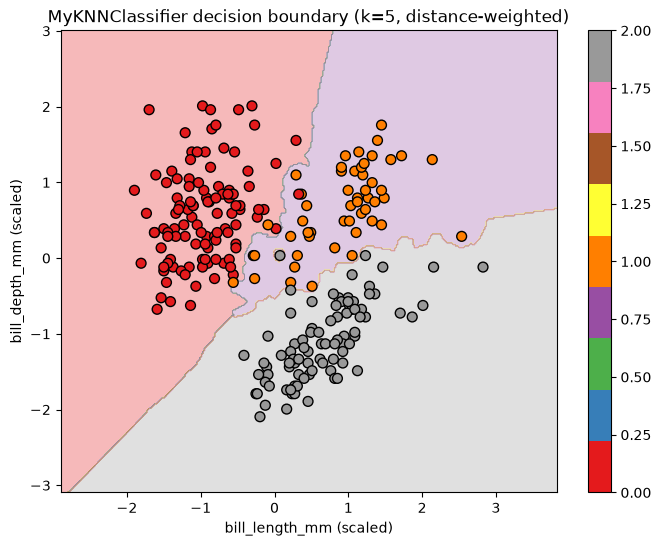

In [5]:
# Use just 2 features for visualization
X_2d = penguins_enc[['bill_length_mm', 'bill_depth_mm']].values
y_2d = y

X_tr_2d, X_te_2d, y_tr_2d, y_te_2d = train_test_split(
    X_2d, y_2d, test_size=0.25, random_state=42, stratify=y_2d)

scaler_2d = StandardScaler()
X_tr_2d_s = scaler_2d.fit_transform(X_tr_2d)
X_te_2d_s = scaler_2d.transform(X_te_2d)

mine_2d = MyKNNClassifier(n_neighbors=5, weights='distance').fit(X_tr_2d_s, y_tr_2d)

# Create mesh grid
h = 0.02
x_min, x_max = X_tr_2d_s[:, 0].min() - 1, X_tr_2d_s[:, 0].max() + 1
y_min, y_max = X_tr_2d_s[:, 1].min() - 1, X_tr_2d_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = mine_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
scatter = plt.scatter(X_tr_2d_s[:, 0], X_tr_2d_s[:, 1], c=y_tr_2d, cmap='Set1', edgecolor='k', s=50)
plt.xlabel('bill_length_mm (scaled)')
plt.ylabel('bill_depth_mm (scaled)')
plt.title('MyKNNClassifier decision boundary (k=5, distance-weighted)')
plt.colorbar(scatter)
plt.show()

### 5. Multi-class probability calibration

Check that predict_proba outputs valid probabilities that sum to 1.

In [6]:
probas = mine.predict_proba(X_te_s)
print('Probability sums (should all be 1.0):', np.unique(np.round(probas.sum(axis=1), 10)))
print('Shape:', probas.shape)
print('First 5 rows:')
print(pd.DataFrame(probas[:5], columns=[f'class_{c}' for c in mine.classes_]).round(3))

Probability sums (should all be 1.0): [1.]
Shape: (84, 3)
First 5 rows:
   class_0  class_1  class_2
0      0.0      1.0      0.0
1      0.0      0.0      1.0
2      1.0      0.0      0.0
3      0.0      0.0      1.0
4      0.0      1.0      0.0


### Summary & key takeaways

- k-NN is a **lazy learner**: `fit()` just stores data; all work happens at `predict()` time.
- Euclidean distance with `StandardScaler` is MANDATORY - unscaled features dominate distances.
- `weights='distance'` lets closer neighbors vote more, often improving accuracy.
- Odd `k` avoids ties in binary classification; for multi-class ties are broken by class order.
- Our pure-NumPy implementation matches sklearn's accuracy on real data (small gaps normal).
- Time complexity: O(n_features * n_train) per prediction - not suitable for huge datasets.